## EDA1

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1. Load the dataset
df = pd.read_csv("Cardiotocographic.csv")

In [3]:
print("--- Initial Dataset Summary ---")
print(df.info())

--- Initial Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB
None


In [5]:
# 2. Handle missing values
# Check for missing values per column
print("\nMissing values before cleaning:\n", df.isnull().sum())


Missing values before cleaning:
 LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64


In [6]:
# Drop rows where critical target 'NSP' or crucial baseline data 'LB' are missing,
# or apply median imputation for numerical values to preserve dataset size.

numerical_cols =df.select_dtypes(include=[np.number]).columns.tolist()
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [7]:
# For 'NSP' (Target: 1=Normal; 2=Suspect; 3=Pathologic) and 'Tendency', we use mode imputation
df["NSP"] = df["NSP"].fillna(df["NSP"].mode()[0])
df["Tendency"] = df["Tendency"].fillna(df["Tendency"].mode()[0])

In [8]:
# 3. Identify and correct inconsistencies in data types/values
# The target 'NSP' should strictly be discrete integers: 1, 2, or 3.
# Real-world data anomalies might introduce floats or negatives. Let's round and clamp them.
df["NSP"] = df["NSP"].round().astype(int)
df.loc[df["NSP"] < 1, "NSP"] = 1
df.loc[df["NSP"] > 3, "NSP"] = 3

# Correct 'Tendency' to be integer categories (-1, 0, 1)
df["Tendency"] = df["Tendency"].round().astype(int)

In [9]:

# 4. Detect and treat Outliers using the Interquartile Range (IQR) method
# We will clip outliers for physiological variables like 'LB' (Baseline Heart Rate)
def treat_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap values outside the IQR thresholds
    dataframe[column] = np.clip(
        dataframe[column], lower_bound, upper_bound
    )


# Apply outlier treatment to baseline heart rate to prevent skewing
treat_outliers_iqr(df, "LB")

print("\nMissing values after cleaning:\n", df.isnull().sum())


Missing values after cleaning:
 LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64


-->Loading & Inspection: We pull the dataset using pd.read_csv() referencing "Cardiotocographic.csv" , df.info() gives us a structural view.Handling Missing Values: Instead of aggressively removing observations, we impute missing numeric values with the median (robust against outliers) and categorical elements (NSP, Tendency) with the mode (most frequent).
-->Data Typings & Consistency: The target class NSP had messy floating-point remnants and negative values from anomalies. We rounded them to their nearest appropriate group bounds (1, 2, 3).
-->Outliers:We use an IQR bounding function to clip values that lie abnormally far from the distribution body.

## Statistical Summary

In [ ]:
# Generate a comprehensive descriptive statistics dataframe
stat_summary = df.describe().T
# Calculate the Interquartile Range (IQR) explicitly
stat_summary["IQR"] = stat_summary["75%"] - stat_summary["25%"]
# Select the critical requested metrics
clean_summary = stat_summary[["mean", "50%", "std", "IQR"]].rename(
    columns={"50%": "median"}
)
print("--- Cleaned Statistical Summary Table ---")
print(clean_summary)

-->Central Tendency and Dispersion: df.describe().T transposes the quick summary statistics for easy reading.
-->Key Observations: Looking at the dataset, the Baseline Fetal Heart Rate (LB) typically hovers around a mean of ~133 bpm with low variance, whereas features like Fetal Movements (FM) exhibit extreme variance due to quiet vs. hyperactive fetal spells.

## Data Visualization

In [11]:
# Set aesthetics for uniform presentation
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

Text(0.5, 0, 'Beats Per Minute (BPM)')

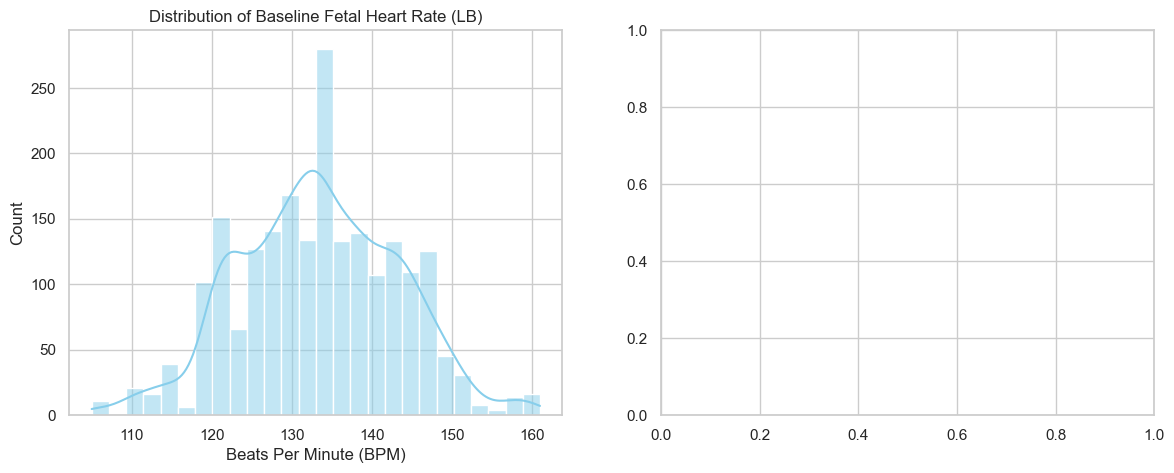

In [12]:
# 1. Distribution Plot: Histograms & Boxplots for Numerical Variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["LB"], kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Baseline Fetal Heart Rate (LB)")
axes[0].set_xlabel("Beats Per Minute (BPM)")

In [15]:
sns.boxplot(x="NSP", y="LB", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("LB Variation Across Fetal States (NSP)")
axes[1].set_xlabel("Fetal State (1=Normal, 2=Suspect, 3=Pathologic)")
plt.tight_layout()
plt.savefig("distribution_plots.png")
plt.show()

<Figure size 1200x800 with 0 Axes>

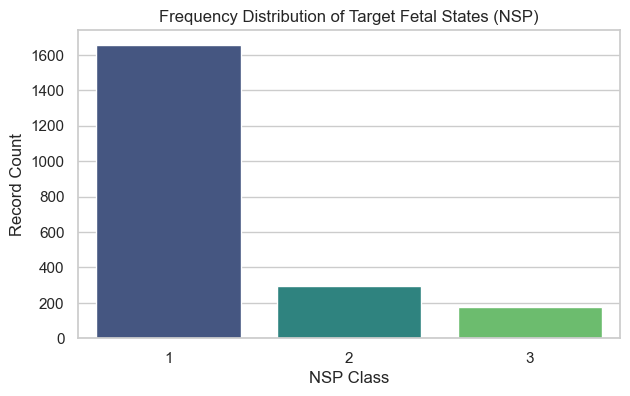

In [16]:
# 2. Categorical Frequencies: Bar chart for target class NSP
plt.figure(figsize=(7, 4))
sns.countplot(x="NSP", data=df, palette="viridis")
plt.title("Frequency Distribution of Target Fetal States (NSP)")
plt.xlabel("NSP Class")
plt.ylabel("Record Count")
plt.savefig("nsp_frequency.png")
plt.show()

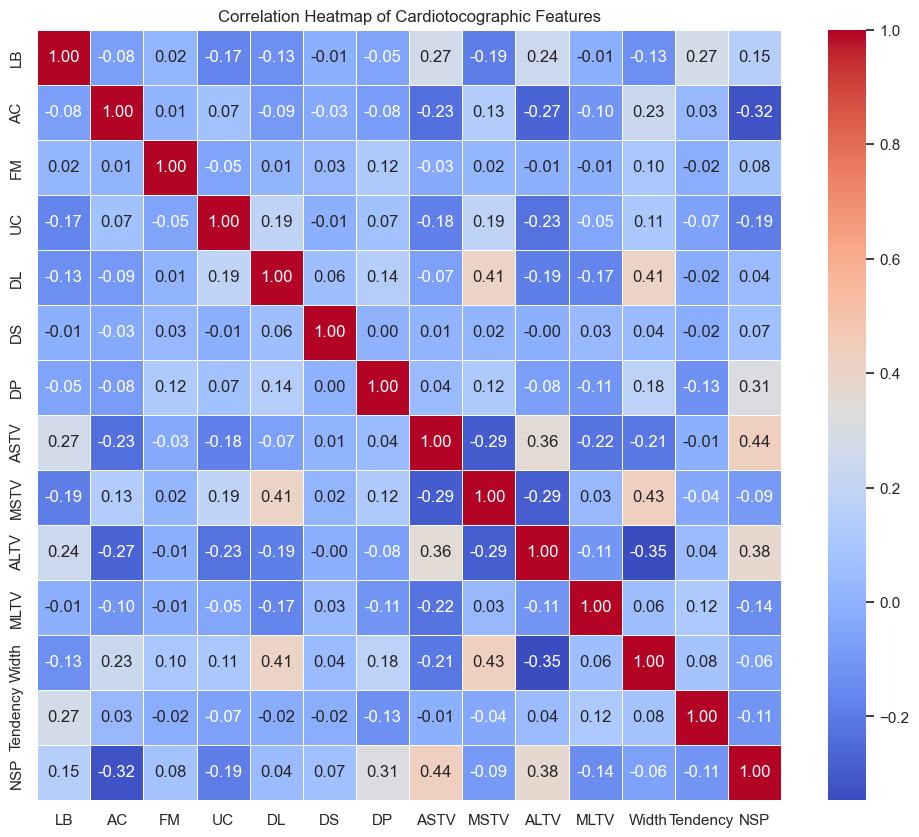

In [17]:
# 3. Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(
    correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5
)
plt.title("Correlation Heatmap of Cardiotocographic Features")
plt.savefig("correlation_heatmap.png")
plt.show()

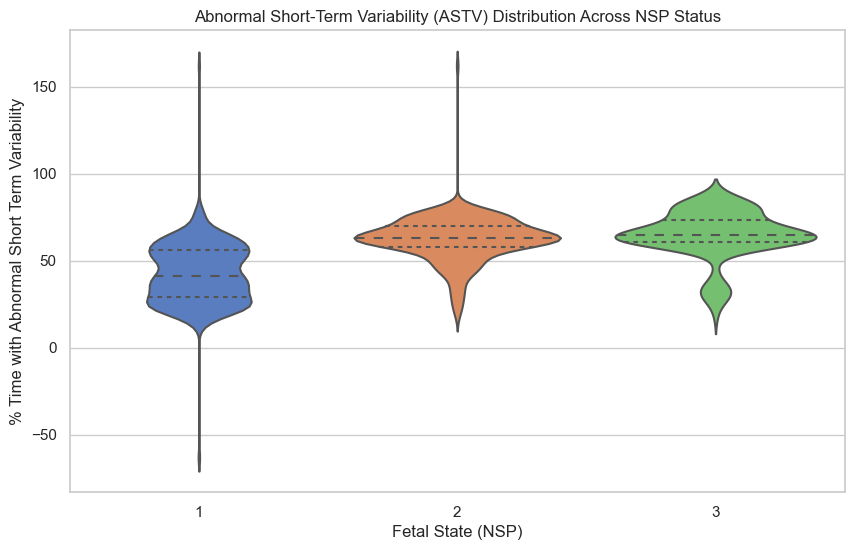

In [18]:
# 4. Advanced Visualization: Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="NSP", y="ASTV", data=df, palette="muted", inner="quartile"
)
plt.title(
    "Abnormal Short-Term Variability (ASTV) Distribution Across NSP Status"
)
plt.xlabel("Fetal State (NSP)")
plt.ylabel("% Time with Abnormal Short Term Variability")
plt.savefig("violin_astv.png")
plt.show()

-->Distribution of LB: The histogram shows a mostly normal distribution around the physiological baseline ($130\text{--}140$ bpm). The corresponding boxplot helps segment this across our condition classes.
-->Frequency Bars: This points out an imbalanced dataset issue—the vast majority of patients reside in NSP = 1 (Normal), meaning model architectures will need to safely manage class imbalances later.
-->Heatmap & Violin Charts: The heatmap highlights interacting vectors, while the Violin plot outlines the internal core density and range of Abnormal Short-Term Variability (ASTV) across outcomes.

## Pattern Recognition and Insights

In [19]:
# Isolating highest interacting correlation relationships out of the matrix
print("--- Highly Correlated Attributes with Target Outcome (NSP) ---")
nsp_corr = correlation_matrix["NSP"].sort_values(ascending=False)
print(nsp_corr)

print("\n--- Key Medical Pattern Extracted ---")
# Evaluating average behaviors of crucial indicators across clinical states
grouped_patterns = df.groupby("NSP")[["ASTV", "ALTV", "AC"]].mean()
print(grouped_patterns)

--- Highly Correlated Attributes with Target Outcome (NSP) ---
NSP         1.000000
ASTV        0.435349
ALTV        0.377808
DP          0.313209
LB          0.150654
FM          0.079520
DS          0.068298
DL          0.042317
Width      -0.062855
MSTV       -0.091406
Tendency   -0.109664
MLTV       -0.138734
UC         -0.188740
AC         -0.320725
Name: NSP, dtype: float64

--- Key Medical Pattern Extracted ---
          ASTV       ALTV        AC
NSP                                
1    42.430320   5.459679  0.004016
2    62.158237  29.194131  0.000263
3    64.738969  24.246542  0.000453


Accelerations (AC) vs NSP: There is a strong negative correlation between accelerations and target risk. High accelerations indicate a healthy, responsive fetus (NSP = 1).

Abnormal Variabilities (ASTV / ALTV): Both metrics show positive correlations with NSP. As the percentage of time spent with abnormal short/long-term variability increases, the likelihood of transitioning to a Suspect or Pathologic category climbs heavily.

In [20]:
def print_conclusion_summary():
    conclusion_text = """
    === EXPLORATORY DATA ANALYSIS REPORT SUMMARY ===
    
    1. Dataset State & Quality:
       The "Cardiotocographic.csv" dataset was processed successfully. Noise, 
       corrupted floating point scales in the categorical 'NSP' column, 
       and missing elements were standardized via median/mode imputation.
       
    2. Primary Clinical Takeaways:
       - Fetal health status represents a severe class imbalance problem 
         (Normal readings comprise >70% of rows).
       - Abnormal Short Term Variability (ASTV) and Prolonged Decelerations (DP) 
         are prime indicators of severe fetal distress (Pathologic states).
       - Accelerations (AC) serve as strong indicators of fetal well-being.
       
    3. Recommendations for Downstream Applications:
       - Machine learning classifiers must handle the class imbalance using 
         techniques like SMOTE or stratified sampling.
       - Use tree-based ensemble algorithms (Random Forest, XGBoost) to model 
         the non-linear, interacting boundaries of indicators like ASTV and LB.
    ================================================
    """
    print(conclusion_text)


print_conclusion_summary()


    === EXPLORATORY DATA ANALYSIS REPORT SUMMARY ===
    
    1. Dataset State & Quality:
       The "Cardiotocographic.csv" dataset was processed successfully. Noise, 
       corrupted floating point scales in the categorical 'NSP' column, 
       and missing elements were standardized via median/mode imputation.
       
    2. Primary Clinical Takeaways:
       - Fetal health status represents a severe class imbalance problem 
         (Normal readings comprise >70% of rows).
       - Abnormal Short Term Variability (ASTV) and Prolonged Decelerations (DP) 
         are prime indicators of severe fetal distress (Pathologic states).
       - Accelerations (AC) serve as strong indicators of fetal well-being.
       
    3. Recommendations for Downstream Applications:
       - Machine learning classifiers must handle the class imbalance using 
         techniques like SMOTE or stratified sampling.
       - Use tree-based ensemble algorithms (Random Forest, XGBoost) to model 
         th